# Homework 3 — AI Orchestration with Kestra

This notebook documents my solution to the **Module 3 homework of [LLM Zoomcamp](https://github.com/DataTalksClub/llm-zoomcamp/blob/main/cohorts/2026/03-orchestration/homework.md) by DataTalksClub**. It's shared as a walkthrough of how each question was approached, in case it's useful to others going through the same material.

The module focuses on AI orchestration using [Kestra](https://kestra.io/) — building RAG pipelines, AI agents, and multi-agent systems as declarative YAML workflows.

> **Note:** This homework is hands-on in the Kestra UI. Screenshots from execution logs are included as evidence for each answer. Code in this notebook is used only to render those screenshots cleanly.

In [1]:
# Custom display helper — renders screenshots, text, and DataFrames in a styled card
from utils import print_html

## Environment Setup

Kestra runs locally via Docker Compose. The [`docker-compose.yml`](docker-compose.yml) file sets up the Kestra server, executor, and a Postgres backend.

```bash
docker compose up -d
```

Once running, the Kestra UI is accessible at `http://localhost:8080`. All flows referenced in this homework are imported from the [`03-orchestration/flows/`](https://github.com/DataTalksClub/llm-zoomcamp/tree/main/03-orchestration/flows) directory of the course repository.

## Q1 — Context Engineering

**Question:** After trying the same prompt in ChatGPT vs Kestra's AI Copilot, what is the primary reason AI Copilot generates better Kestra flows?

The same prompt was run in both ChatGPT (private window, no memory) and Kestra's built-in AI Copilot:

> *"Create a Kestra flow that loads NYC taxi data from CSV to BigQuery"*

ChatGPT produces a plausible-looking flow but uses outdated or hallucinated plugin names and task types. Kestra's AI Copilot produces a working flow with correct, current plugin syntax.

The difference comes down to **context** — the Copilot is given Kestra's current plugin documentation as part of its context window, so it knows exactly which plugins exist, what their task types are called, and how they're configured. ChatGPT has no access to this and falls back on training data, which may be stale or incomplete.

**Steps taken:**
1. Opened ChatGPT in a private browser window (no memory, no plugins): https://chatgpt.com
2. Entered the prompt: *"Create a Kestra flow that loads NYC taxi data from CSV to BigQuery"*
3. Repeated the same prompt in Kestra's AI Copilot
4. Compared the outputs — AI Copilot produced correct plugin names and task syntax; ChatGPT did not

**✅ Answer: AI Copilot has access to current Kestra plugin documentation**

This is the core principle of **context engineering** — the model itself isn't more powerful, but the *context* it receives is richer and more accurate. Providing the right information at inference time is often more impactful than model size alone.

## Q2 — RAG vs No RAG

**Question:** Run `1_chat_without_rag.yaml` and `2_chat_with_rag.yaml`. The non-RAG response about Kestra 1.1 features is best described as?

Both flows ask the same question about Kestra 1.1 features. The difference is whether the model receives retrieved documentation as context.

**Without RAG** (`1_chat_without_rag.yaml`) — the model answers entirely from training data. The response sounds confident and detailed, but the features described (Worker Groups, Plugin Management UI, Namespace-based Permissions, Flow Diff, Blueprints) are fabricated or from different releases — none match the actual Kestra 1.1 release notes.

**With RAG** (`2_chat_with_rag.yaml`) — the model receives retrieved Kestra documentation as context. The response correctly identifies real Kestra 1.1 features: the no-code dashboard editor, multi-agent AI systems, "Fix with AI", the Human Task plugin, improved air-gapped support, and dozens of new plugins.

This is a clear demonstration of **hallucination**: without grounding, LLMs fabricate plausible-sounding but incorrect answers. RAG fixes this by anchoring the model to verified source content.


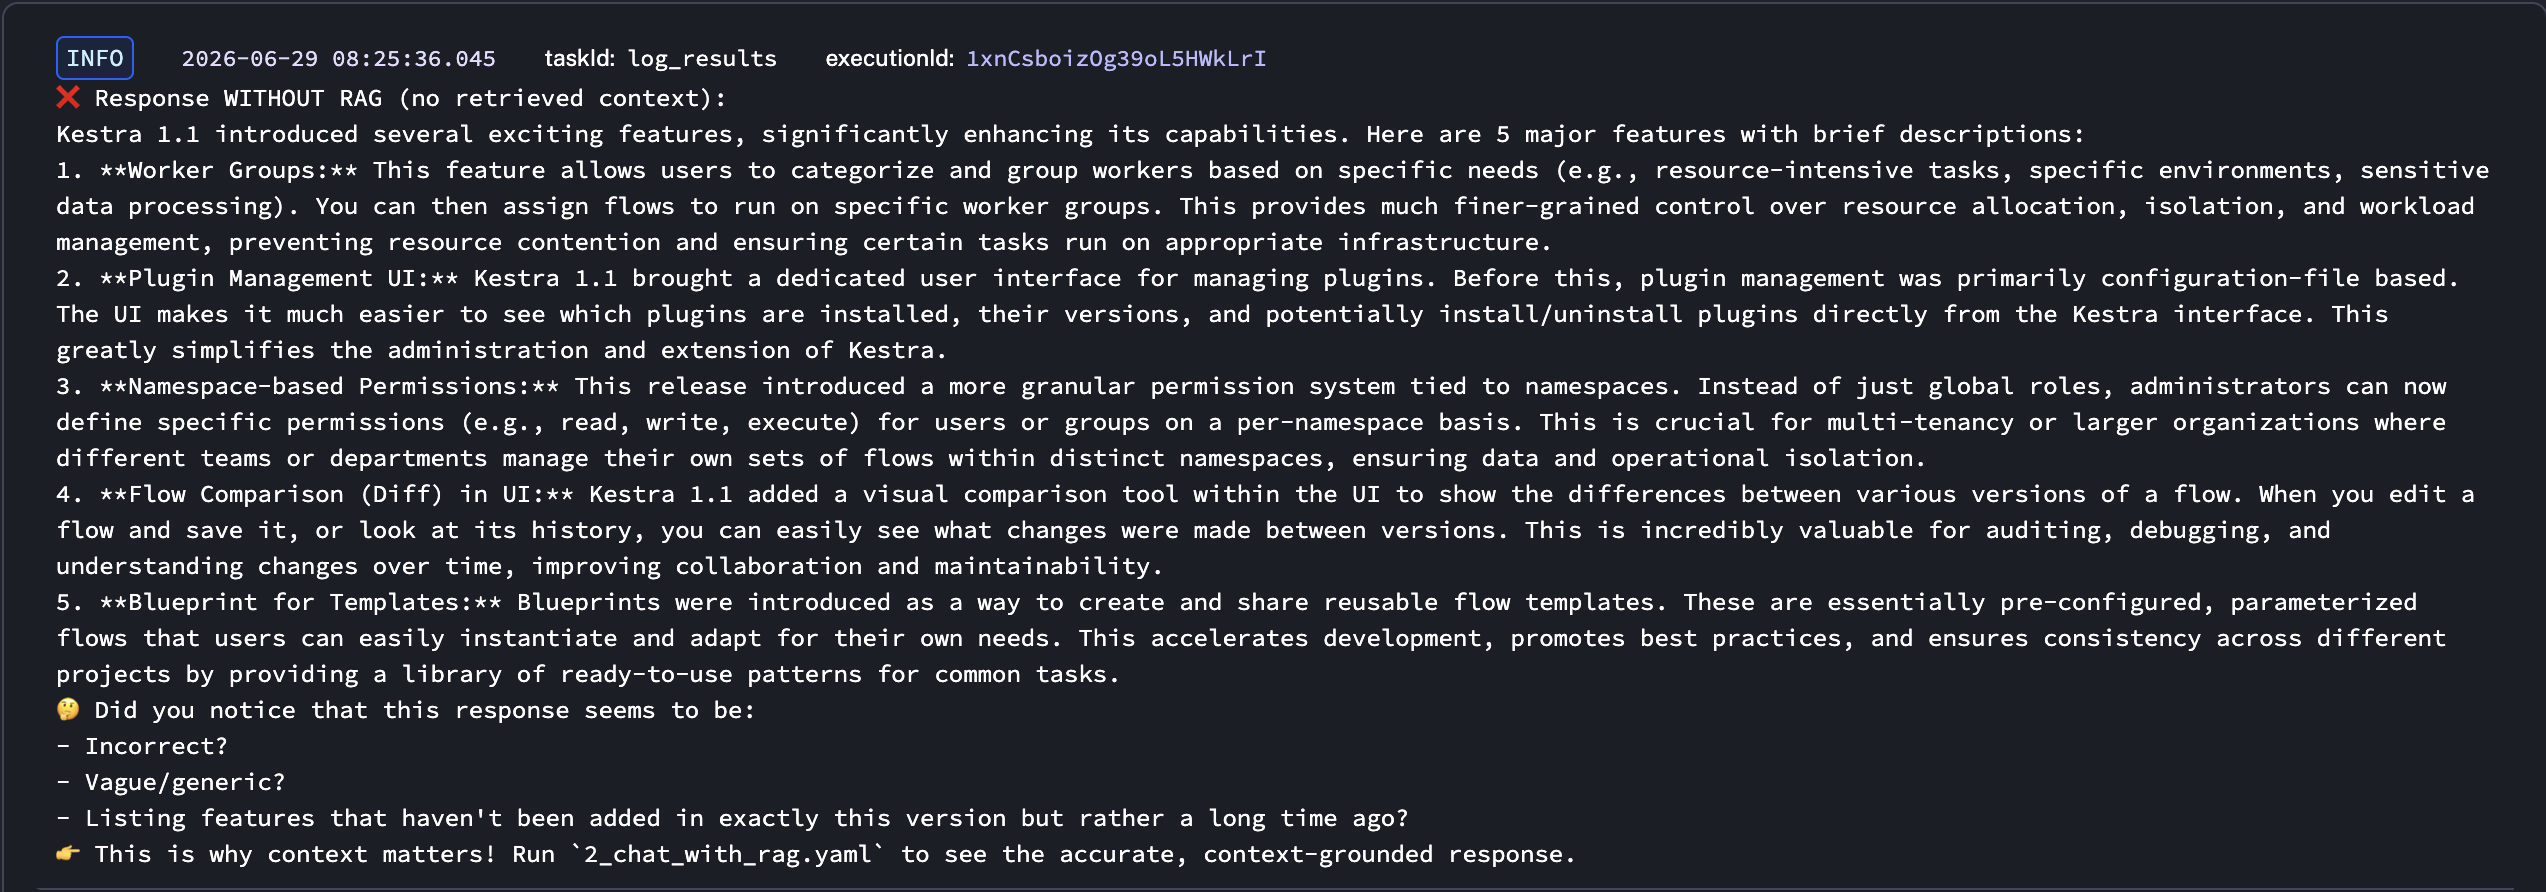

In [16]:
# Execution log — response WITHOUT RAG
print_html("1_chat_without_rag.png", title="❌ Without RAG", is_image=True)


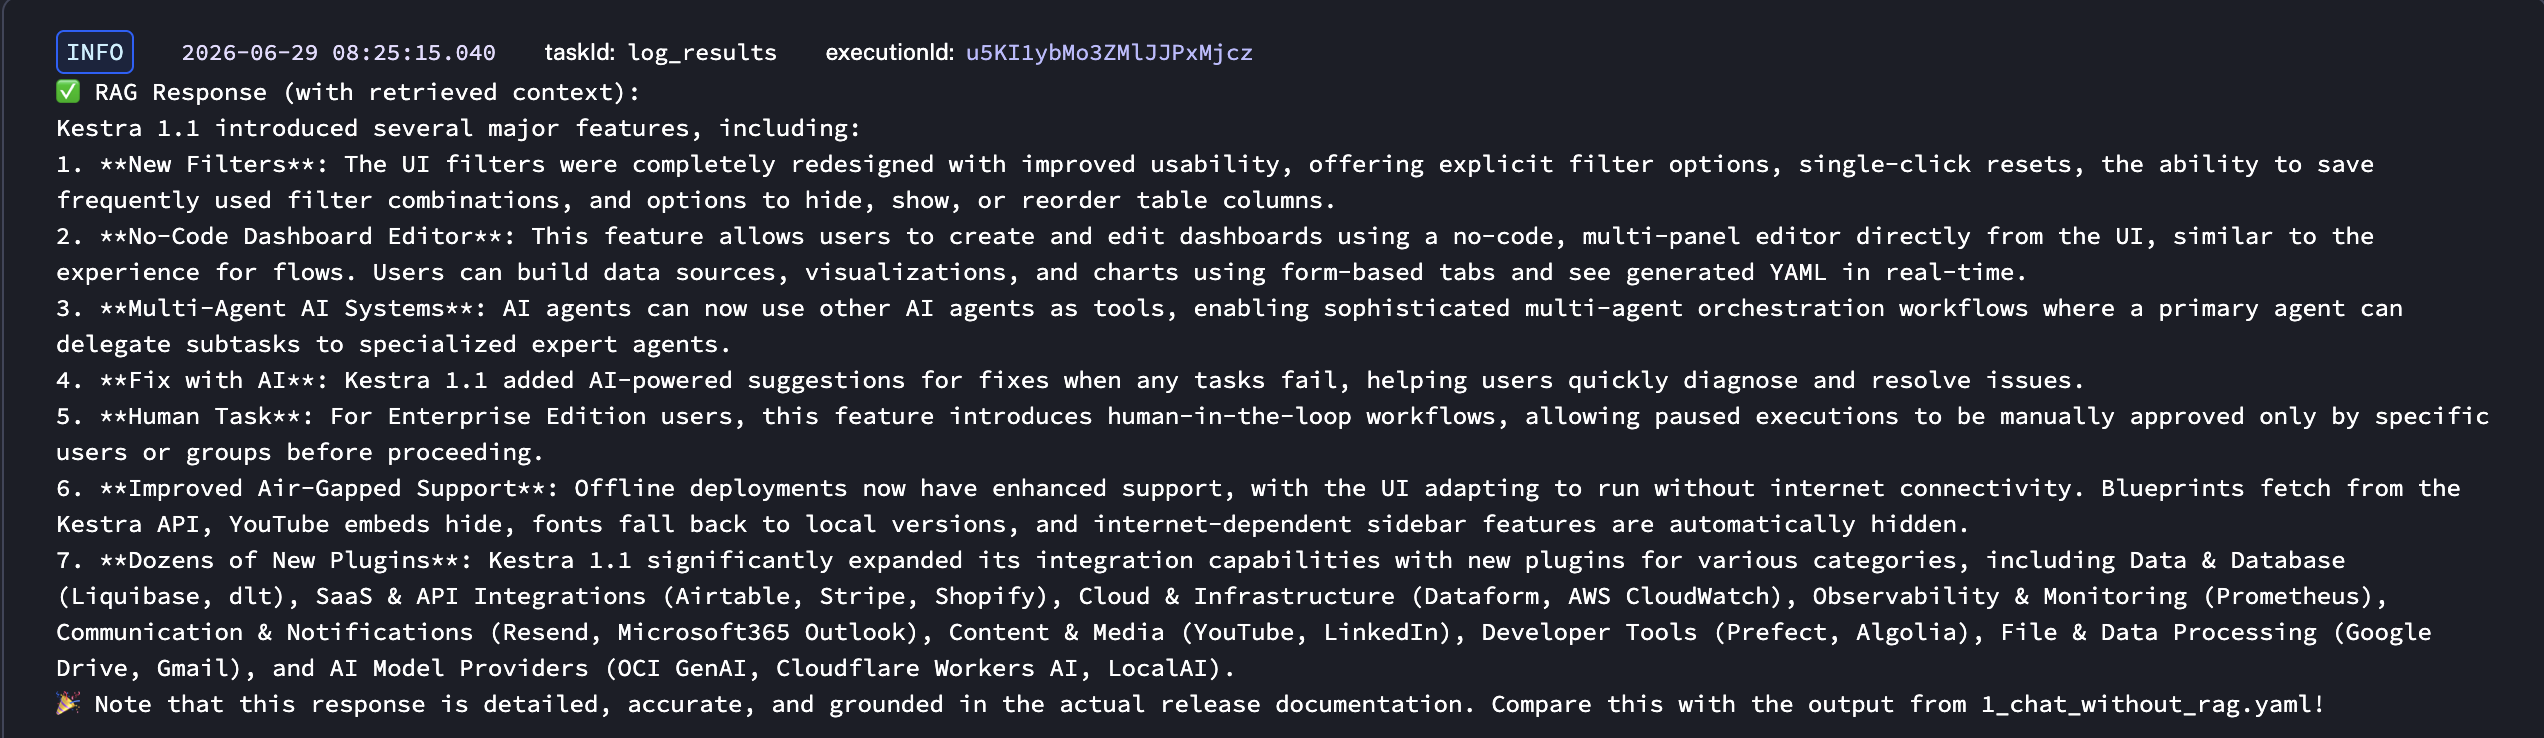

In [15]:
# Execution log — response WITH RAG
print_html("2_chat_with_rag.png", title="✅ With RAG", is_image=True)

**✅ Answer: Vague, generic, or fabricated — the model guesses from training data**

The non-RAG response listed five detailed, confident-sounding features — none of which match the actual [Kestra 1.1 release notes](https://kestra.io/blogs/release-1-1). This illustrates why RAG is essential for grounding LLM responses in factual, up-to-date information.

## Q3 — Token Usage: Short Summary

**Question:** Run `4_simple_agent.yaml` with `summary_length = short`. What is the approximate output token count for `multilingual_agent`?

`4_simple_agent.yaml` is a multi-agent flow with two chained agents:
- `multilingual_agent` — summarizes an input text (length controlled by `summary_length`)
- `english_brevity` — condenses the multilingual agent's output into 1 sentence in English

Token usage is logged by the `log_token_usage` task at the end of each run.

**✅ Answer: 60–100 tokens**

From the execution log: `multilingual_agent` produced **69 output tokens** with `summary_length = short`.


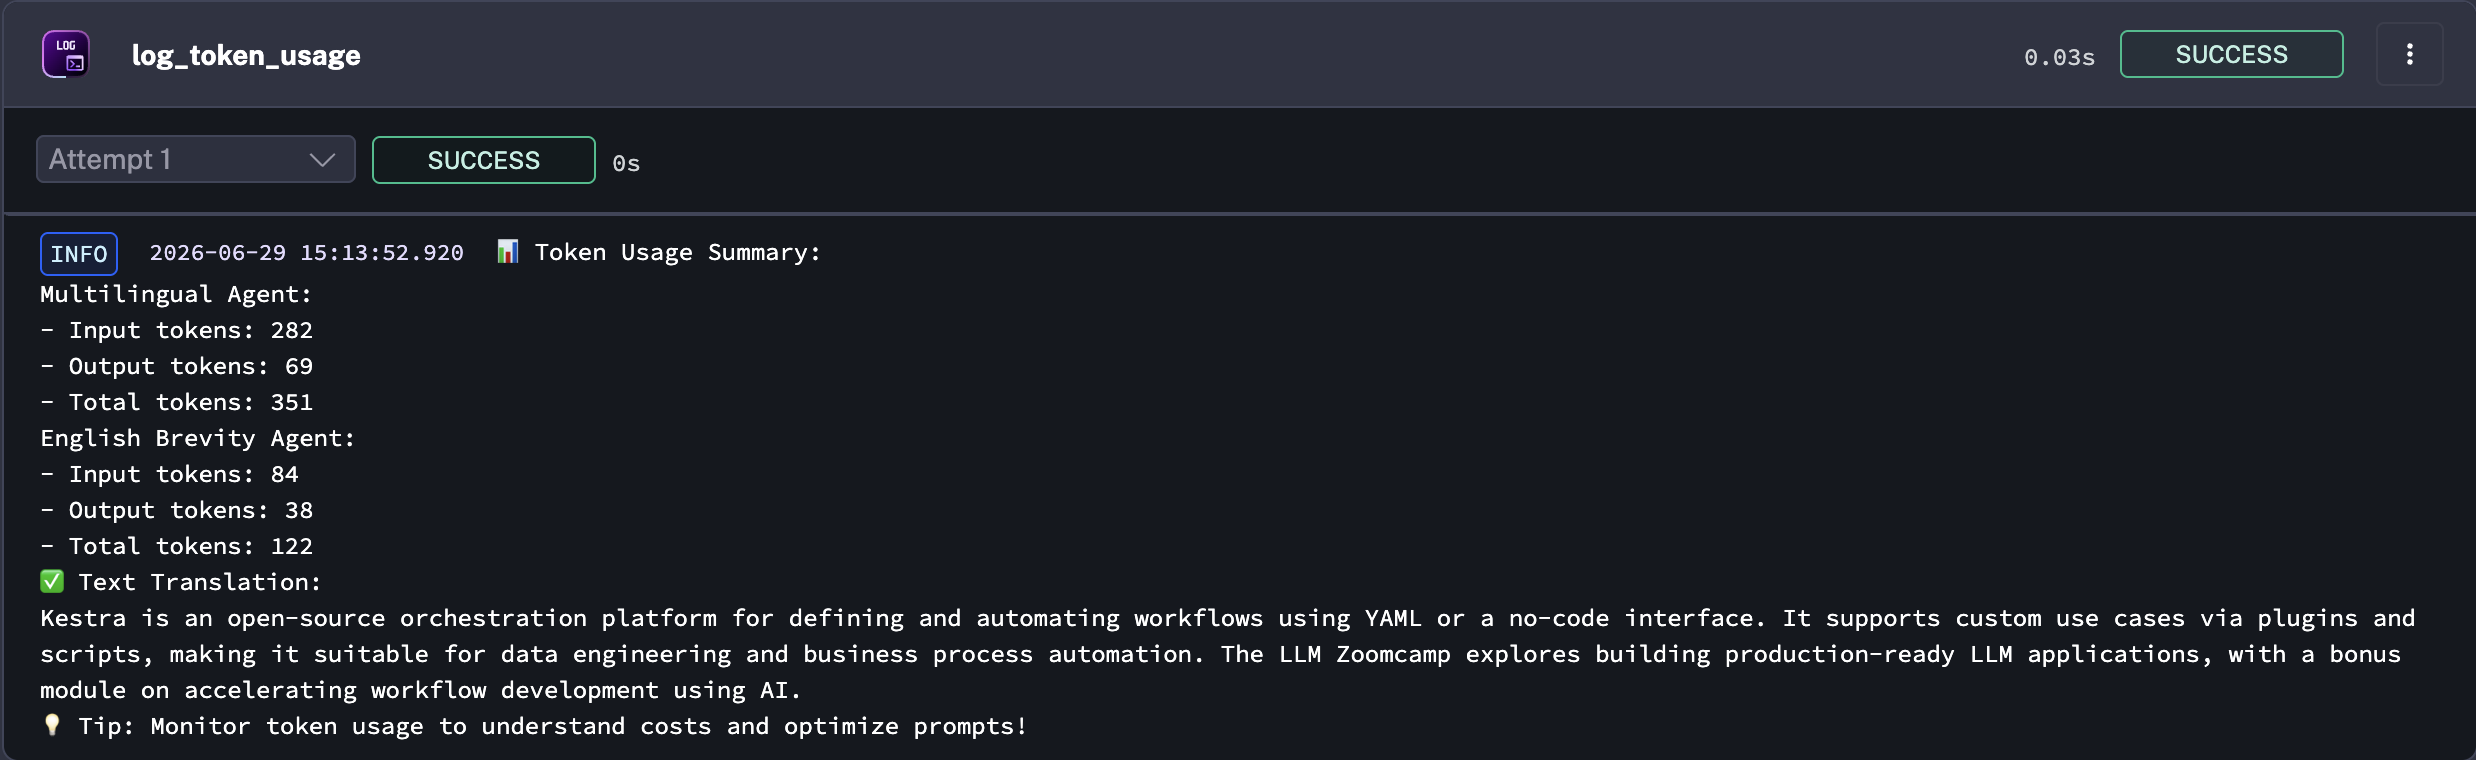

In [14]:
# Execution log — token usage for summary_length = short
print_html("4_simple_agent.png", title="Token Usage — short summary", is_image=True)

## Q4 — Token Usage: Long Summary

**Question:** Run `4_simple_agent.yaml` with `summary_length = long`. How many times more output tokens does the long summary use compared to the short summary?|

**✅ Answer: 2–5× more**

From the execution logs:
- Short summary (`summary_length = short`): **69 output tokens**
- Long summary (`summary_length = long`): **189 output tokens**
- Ratio: 189 / 69 ≈ **2.7×**

Longer summaries consume more output tokens because the model generates more text — directly increasing inference cost.


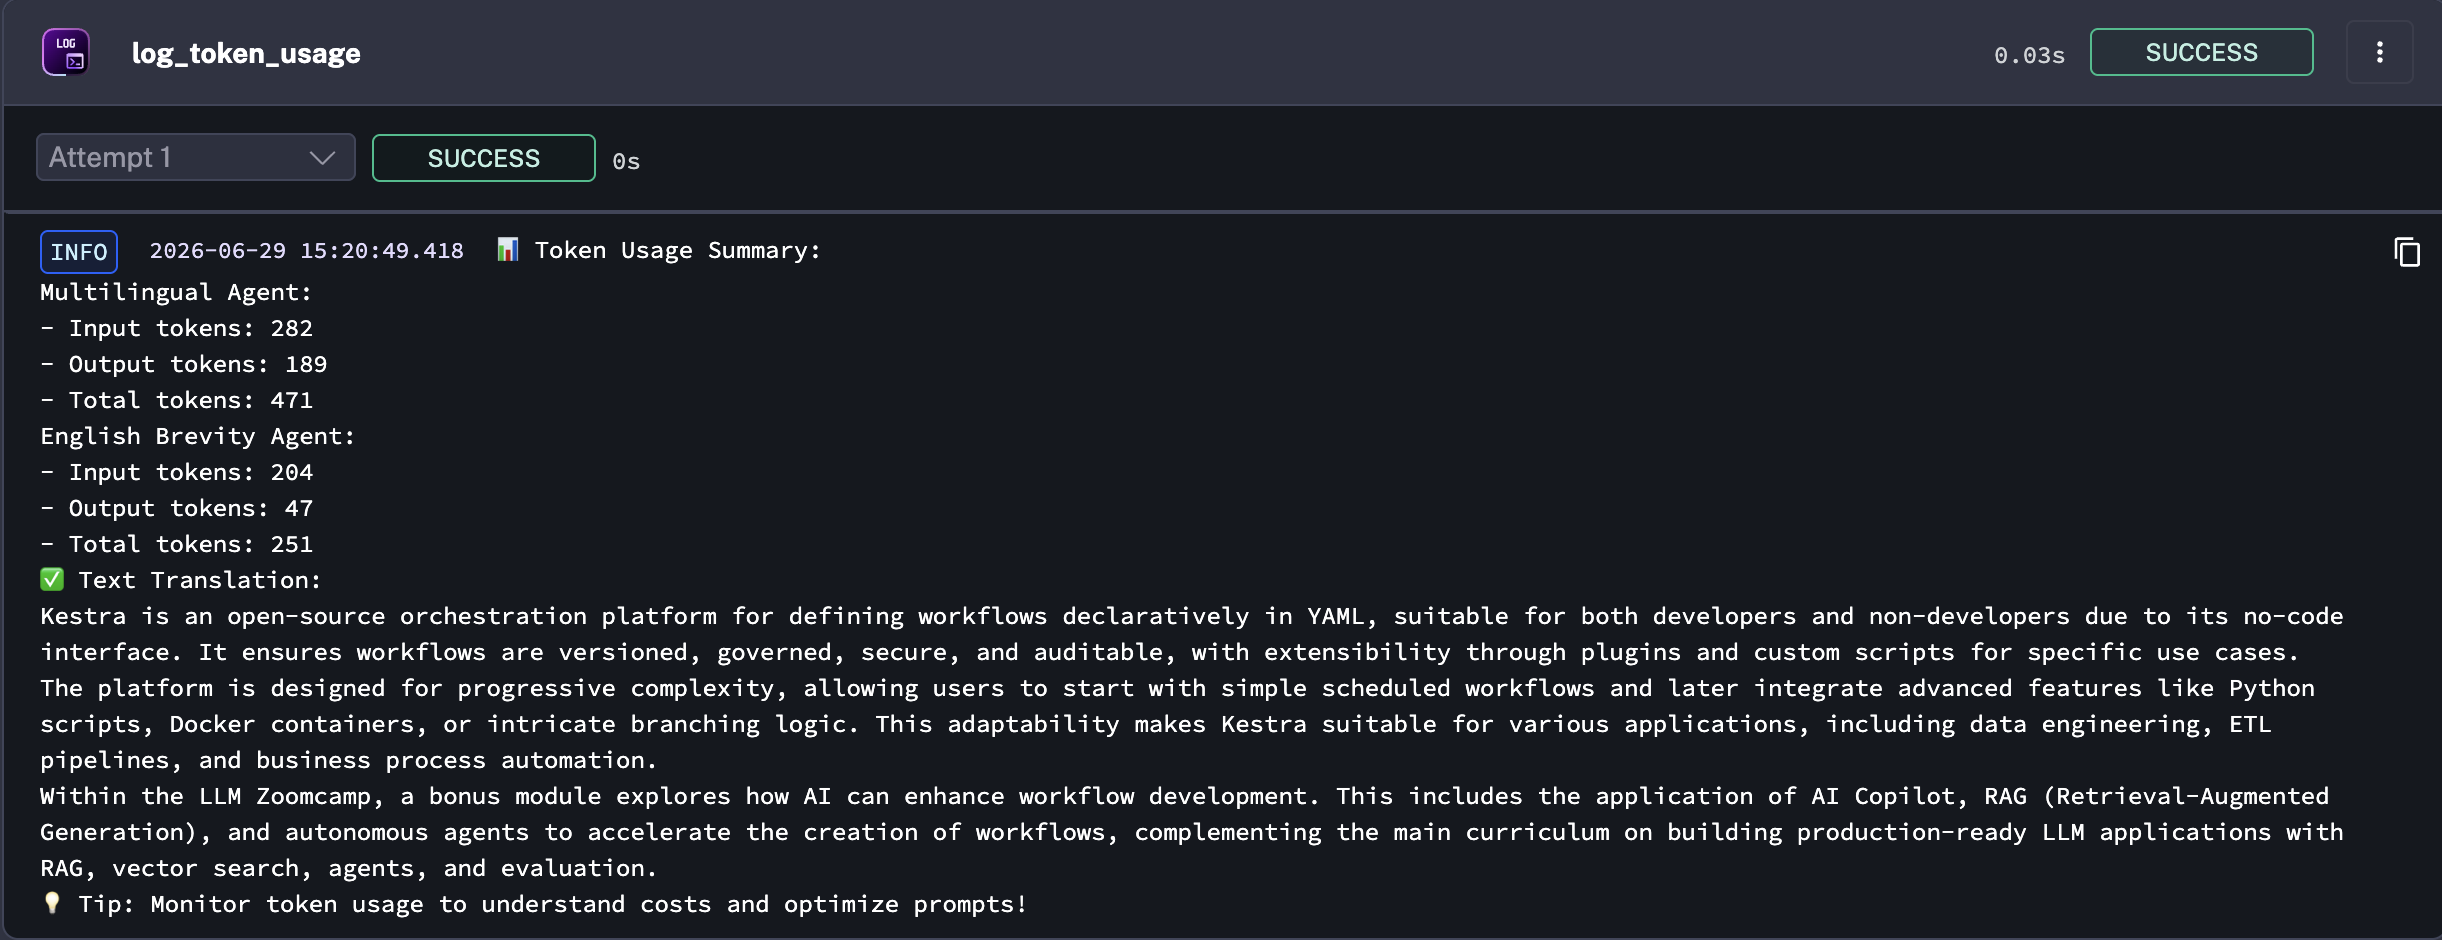

In [17]:
# Execution log — token usage for summary_length = long
print_html("4_simple_agent_long.png", title="Token Usage — long summary", is_image=True)

## Q5 — Modifying a Flow

**Question:** Change the `english_brevity` task prompt from 1 sentence to 3 sentences. Run with `summary_length = long`. How does the output token count compare to the original 1-sentence version?

The `english_brevity` task condenses the multilingual agent's output into a fixed number of sentences. Changing 1 → 3 directly instructs the model to produce more text, which should increase output token usage.

**Steps taken:**
1. Opened `4_simple_agent.yaml` in the Kestra flow editor
2. Located the `english_brevity` task prompt — changed *"exactly 1 sentence"* → *"exactly 3 sentences"*
3. Saved the flow and ran it with `Summary Length = long`

**Comparison:**
| Version | `english_brevity` output tokens |
|---|---|
| Original (1 sentence, long) | 47 tokens |
| Modified (3 sentences, long) | 90 tokens |
| Ratio | ≈ **1.9× more** |


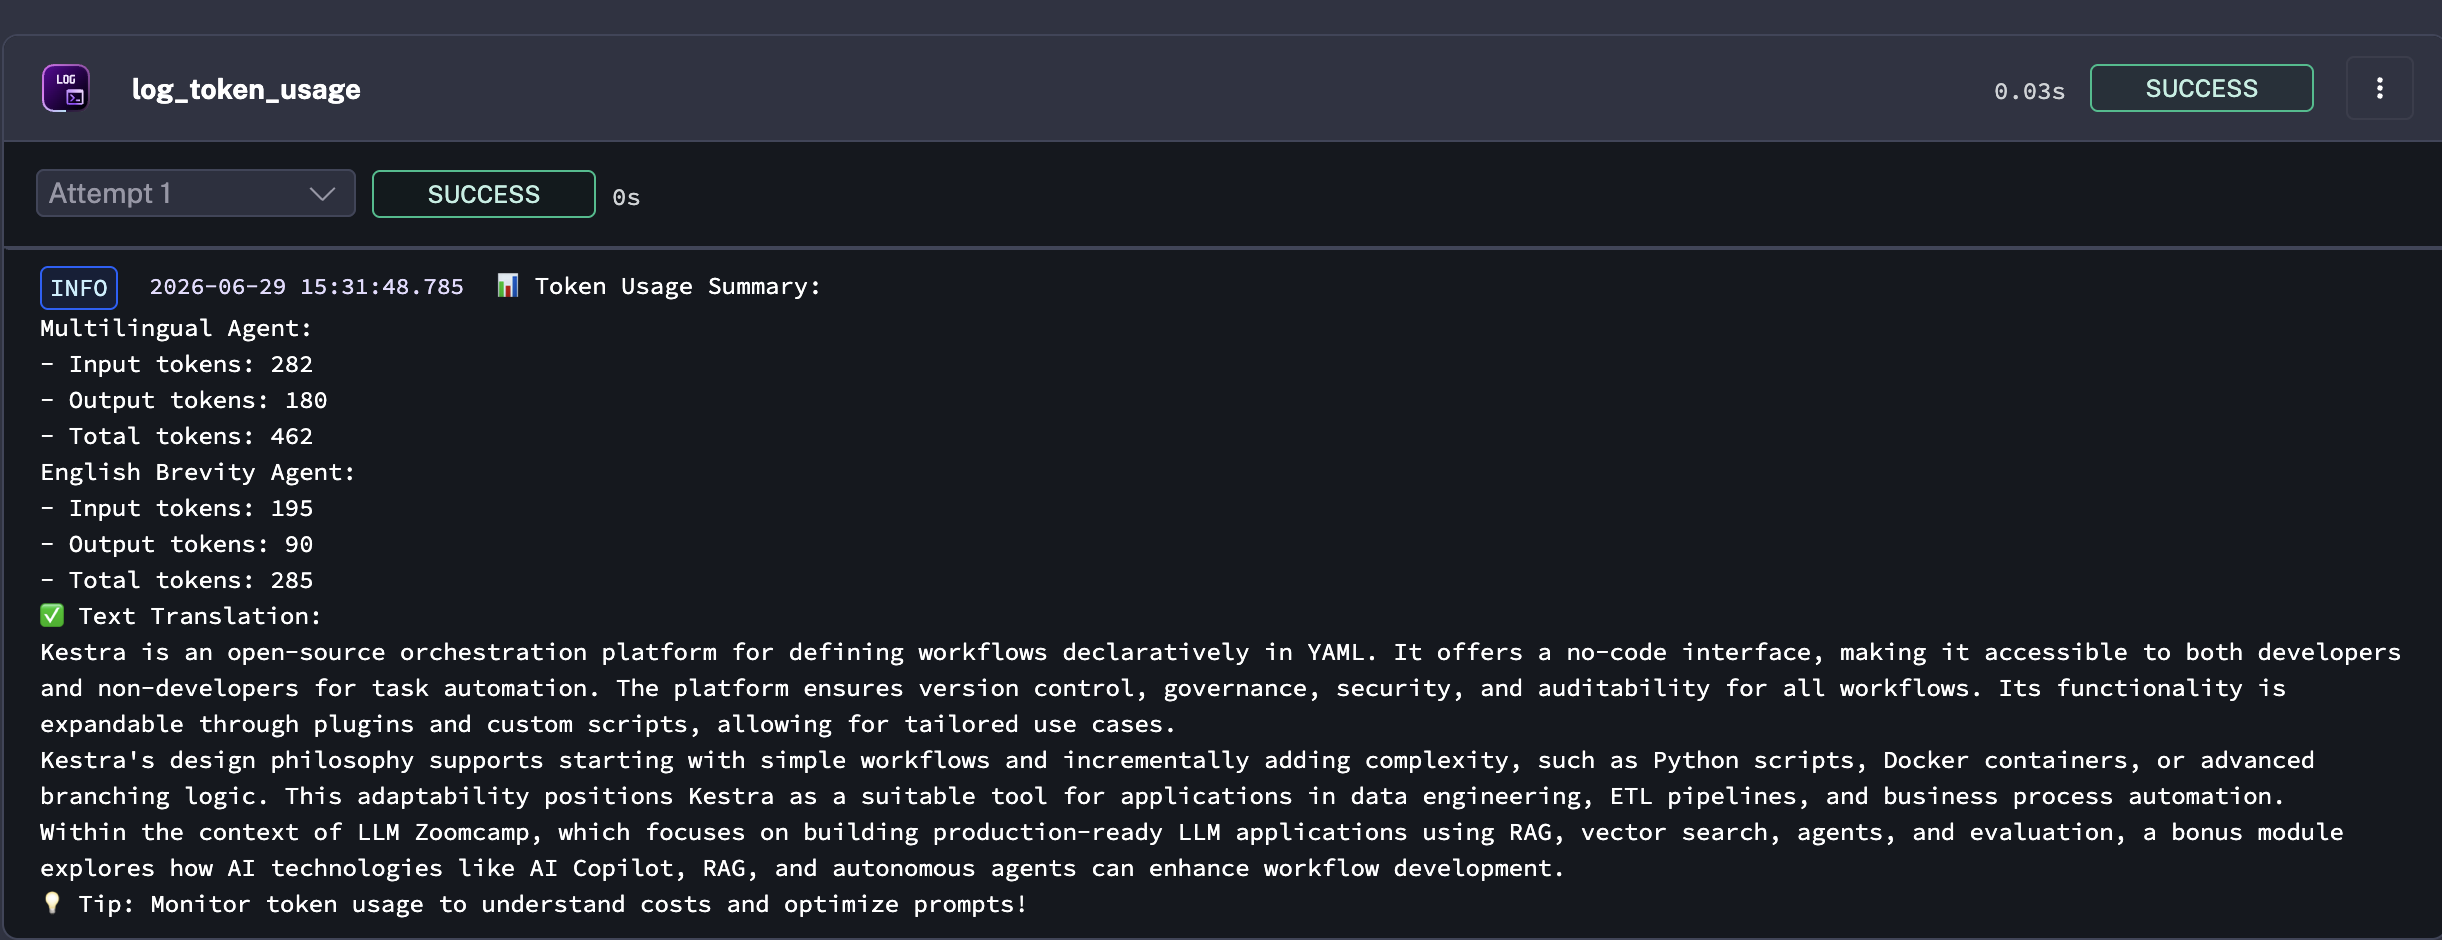

In [18]:
# Execution log — token usage after modifying english_brevity to 3 sentences
print_html("4_simple_agent_modify_flow.png", title="Token Usage — modified flow (3 sentences)", is_image=True)

In [20]:
# Q5 answer summary
original = 47
modified = 90
ratio = modified / original
print(f"Original (1 sentence): {original} output tokens")
print(f"Modified (3 sentences): {modified} output tokens")
print(f"Ratio: {ratio:.2f}x — closest answer: ✅ 2-4x more")

Original (1 sentence): 47 output tokens
Modified (3 sentences): 90 output tokens
Ratio: 1.91x — closest answer: ✅ 2-4x more


## Q6 — Best Practices: When to Use Agents vs Traditional Workflows

**Question:** For production workflows requiring deterministic, repeatable results with strict compliance requirements (e.g., financial reporting, highly regulated industries), which approach is most appropriate?

**✅ Answer: Use traditional task-based workflows for predictability and auditability**

AI agents are powerful but inherently non-deterministic — the same prompt can produce different outputs or tool-call sequences across runs. For regulated environments this is a liability, not a feature.

Traditional task-based workflows (like standard Kestra flows without AI agents) offer:
- **Determinism** — the same inputs always produce the same outputs
- **Auditability** — every step is logged, versioned, and traceable
- **Compliance** — predictable behavior satisfies audit and regulatory requirements

The module makes this trade-off explicit: reach for agents when flexibility and adaptation matter; reach for traditional workflows when repeatability and accountability are non-negotiable.